<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/04_pytorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets

A custom dataset

How do we build a model with PyTorch that can work your own custom dataset? Well, you need to make it compatible with PyTorch.

## Domain Libraries

  - TorchVision for vision data
  - TorchText for text data
  - TorchAudio for audio data such as music (like Shazam does)
  - TorchRec for Product Recommendation

This is something to keep in mind, because each of these domain libraries has a `Datasets` module that helps you work with datasets from your source.

`torchvision.datasets`, `torchtext.datasets`, `torchaudio.datasets` and so on...

They have functions so that you can create your dataset. The bonus is `TorchData`, which was in beta back in 2022, but maybe now it is not.

# What we'll do: FoodVision Mini

Build an image classification model or image recognition app, from a dataset.
We'll write some code to load up images of food.

# Important tip: Toy Dataset from your Dataset

Reduce the number of categories, and take a reduced amount of the dataset, say 10%, and then if your model works for that, you can try upscaling. But yeah try in a smaller portion of your dataset.

# 1. Device-Agnostic Code

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
torch.__version__

'2.6.0+cu124'

In [ ]:
from torch import nn

## 1. Get Data

Our dataset is a subset of the Food101 Dataset.

Food101 has 101 different classes of food, 1000 images per class (750 training / 250 testing)

Our version will have 3 classes of food, and only 10% of the images (~75 training / 25 testing)

We do this so that we can experiment faster

In [ ]:
import requests
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
  print(f"{image_path} directory already exists... skipping download")
else:
  print(f"{image_path} directory does not exist yet, creating...")
  image_path.mkdir(parents=True, exist_ok=True)
  print("Path created.")

# Download pizza, steak, and sushi data.
with open(data_path / "pizza_steak_sushi.zip", "wb") as f: #wb is write binary
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza, steak, sushi data...")
  f.write(request.content) #It will write to data_path / pizza_steak_sushi.zip

# Unzip the zip file we downloaded, containing pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref: #Now read permissions, instead of writing it | `zip_ref` is a common example
  print("Unzipping the data")
  zip_ref.extractall(image_path) #It extracts into the image_path we defined


data/pizza_steak_sushi directory does not exist yet, creating...
Path created.
Unzipping the data


# 2. Becoming one with the data (Data Preparation and Data Exploration)



In [ ]:
import os

# See what's going on in each directory
def walk_through_dir(dir_path):
  """ Walks through `dir_path` returning its contents.
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    #Will go through our target directories, printing information from each directory
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")


In [ ]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'


In [ ]:
# Setup train and testing paths

train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

We're telling it where to look for training images, and where to look for testing images.

There is a standard for storing images, and it's simply to create a folder per category, and store images that correspond to that category there, so

- train/dog
  - train/dog/x.png
  - train/dog/y.png
  - train/dog/[...]/z.png
- train/cat
  - train/cat/a.png
  - train/cat/b.png
  - train/cat/[...]/c.png

## 2.1 Visualizing and image

1. Get all of the image paths
2. Pick a random image path using Python's `random_choice()`
3. Get the image class name using `pathlib.Path.parents.stem`
4. Open the image with Python's PIL
5. We'll show the image and print metadata

### Pillow

A way to process images with Python. PIL is a library for handling images in Python.

In [ ]:
import random
from PIL import Image

random.seed(42)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg")) # glob joins all files that suit a certain pattern
# We want every image path, so everything train or test / everything pizza, steak, sushi / any image name

image_path_list

[PosixPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/309892.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/540882.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/971934.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2236338.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/714866.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/930553.jpg'),
 PosixPath('data/pizza_steak_s

Now we've got a list of every single image within our `pizza_steak_sushi` folder

We'll select a random image and plot it.

Random image path: data/pizza_steak_sushi/test/sushi/1245193.jpg
Image class: sushi
Image height: 295
Image width: 512


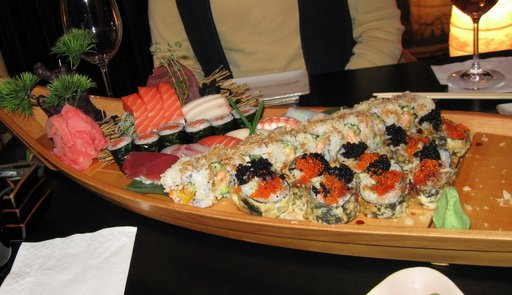

In [ ]:
# 2. Pick random image
random_image_path = random.choice(image_path_list)
random_image_path

# 3. Get image class from path name (since the folder is the name of the category, going by our standard)
image_class = random_image_path.parent.stem
image_class

# 4. Open image with PIL
img = Image.open(random_image_path)

# 5. Print metadata. Opening our image gives us some metadata from it
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

Text(0.5, 1.0, 'sushi')

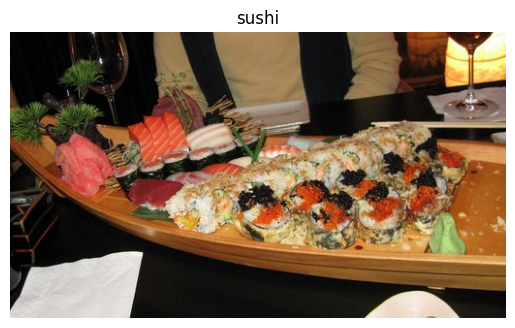

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis(False)
plt.title(image_class)

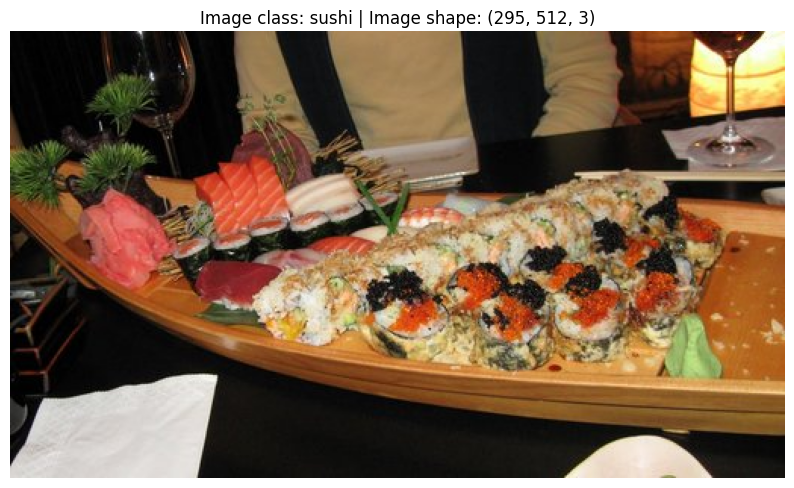

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}")
plt.axis(False);

Notice the format is color channels last!

# 3. Transforming Data

Before we can use our image data with PyTorch, we need a way to turn it into tensor, and that's always the case for PyTorch.

1. Turn your target data into tensors
2. Turn it into a `torch.utils.data.Dataset` and after that, into a `torch.utils.data.DataLoader`
  - A DataLoader is an iterable form of our dataset.




In [ ]:
# Data into tensors
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms # Since we're working with images

## 3.1 Transforming data with `torchvision.transforms`

Turning our images from jepgs into tensor representations

Transforms help you get your images ready to be used with a model / perform data augmentation.

In [ ]:
#data_transform = transforms.Compose #Combine transforms
#data_transform = nn.Sequential() # To combine transforms, you can also do this
data_transform = transforms.Compose([
    # Resize our images to 64 * 64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal axis
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch Tensor
    transforms.ToTensor()
])

In [ ]:
# data_transform(img_as_array) # Won't work
data_transform(img).shape, data_transform(img).dtype

(torch.Size([3, 64, 64]), torch.float32)

Note that it changed to color channels first!

Let's visualize the image, and compare it to the original image.

In [ ]:
image_path_list

[PosixPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/309892.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/540882.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/971934.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2236338.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1152100.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/714866.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1503858.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/930553.jpg'),
 PosixPath('data/pizza_steak_s

In [ ]:
def plot_transformed_images(image_paths : list, transform, n=3, seed=42):
  """
  Selects random images from a path of images and loads/transforms them then
  plots the original vs the transformed version
  """
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2) #1 row, 2 columns
      ax[0].imshow(f)
      ax[0].set_title(f"OG\nSize: {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      transformed_image = transform(f) #since color channels were moved to the first spot, it may give an error
      transformed_image = transformed_image.permute(1, 2, 0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

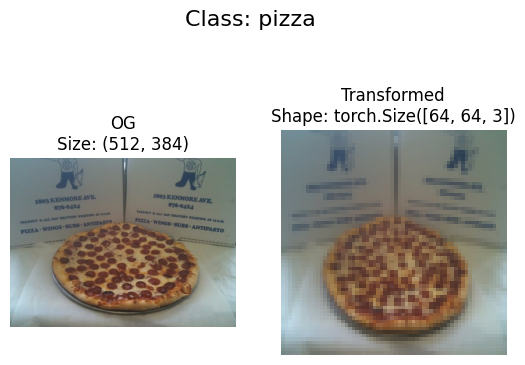

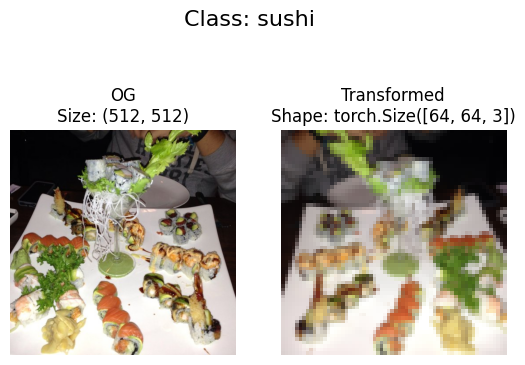

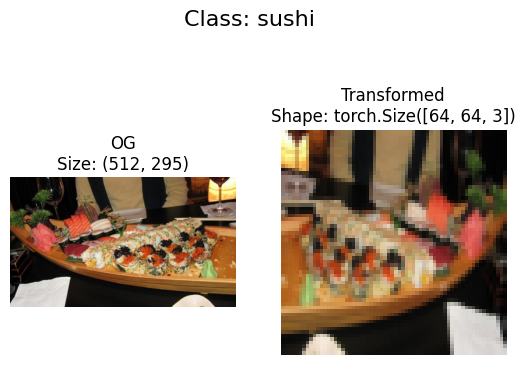

In [ ]:
plot_transformed_images(
    image_paths=image_path_list,
    transform=data_transform,
    seed=31
)

We chose 64*64 since we're using TinyVGG again

# 4. Loading image data using `ImageFolder`

We can load image classification data using `torchvision.datasets.Imagefolder`

In [ ]:
# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform, #Transform for the images
    target_transform=None #Transform for the label
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform #You can also jut not specify the target_transform
)

In [ ]:
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [ ]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
len(train_data), len(test_data)

(225, 75)

In [ ]:
type(train_data)

torchvision.datasets.folder.ImageFolder

In [ ]:
train_data[0]

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [ ]:
img, label = train_data[0]
label, img

(0,
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

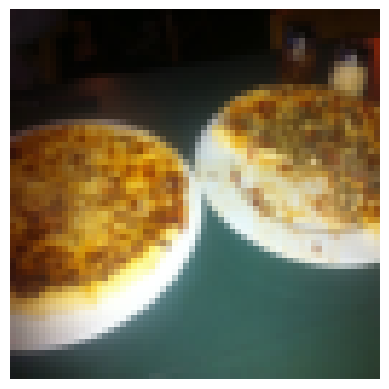

In [ ]:
plt.imshow(img.permute(1, 2, 0))
plt.axis(False)

In [ ]:
print(f"Image tensor: {img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor: tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

In [ ]:
# Rearrange the order of dimensions
img_permute = img.permute(1, 2, 0)

# Print out different shapes
img.shape, img_permute.shape

(torch.Size([3, 64, 64]), torch.Size([64, 64, 3]))

Text(0.5, 1.0, '0')

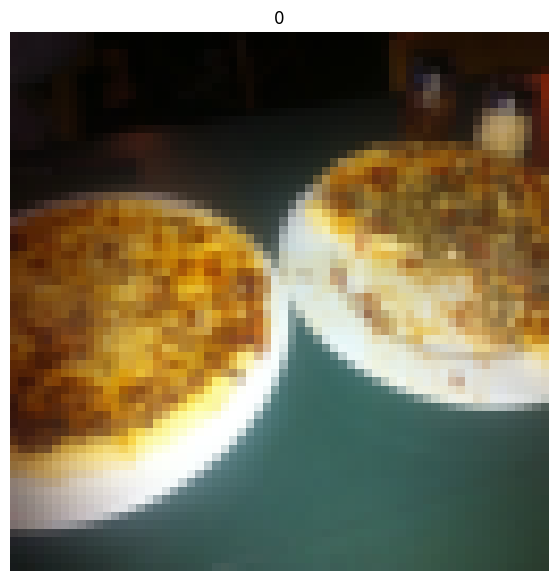

In [ ]:
plt.figure(figsize=(10, 7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(label)

## 4.2 Turn loaded images into DataLoaders

A. `DataLoader` is going to help us turn our `Dataset`s into iterables, and we can customise the `batch_size` so our model can see `batch_size` images at a time.

This helps us leverage the available memory while not running out of it, which would happen if we tried processing all images at once (since there are so many).

In [ ]:
import os
os.cpu_count()

2

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    num_workers= os.cpu_count(), #How many cores or CPU Cores are going to be used to load your data. The higher the better.
    shuffle=True #So our model does not recognize the order at all
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    num_workers=1,
    shuffle=False
)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7a7833357710>,
 <torch.utils.data.dataloader.DataLoader at 0x7a783354c890>)

In [ ]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [ ]:
len(train_data), len(test_data)

(225, 75)

In [ ]:
img, label = next(iter(train_dataloader))

print(f"Image label: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image label: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


# 5 Option 2: Loading Image Data with a Custom `Dataset`

1. Want to be able to load images from file
2. Want to be able to get class names from the Dataset
3. Want to be able to get classes as Dictionary from the Dataset

Pros:
  * You can create a `Dataset` out of almost anything, as long as you write the code to load it in
  * You're not limited to PyTorch pre-built `Dataset` functions

Cons:
  * You can create `Dataset` out of almost anything, but that doesn't necessarily mean it will work
  * Using a custom `Dataset` often results in us writing more code, which is prone to error introduction or performance issues

All custom datasets in PyTorch often subclass `torch.utils.data.Dataset`.

What we'll do:
  * Load images from a file
  * get class names from the Dataset
  * Will create the dictionary from the Dataset and make it available

In [ ]:
# building on top of torch.utils.data.Dataset

import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms # Not only import our Images, but also transform them
from typing import Tuple, Dict, List #To put in type hints when we're creating our functions.

In [ ]:
# This will be our equivalent of an Instance of torchvision.dataset.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## 5.1 Creating a helper function to get class names

We want a function to:
1. Get class names using `os.scandir()` to traverse a target directory
2. Raise an error if the class names aren't found. If so, we want to hint it might be something wrong with the structure
3. Turn the class names into a dict and a list and return them.

In [ ]:
# Setup path for target directory
target_directory = train_dir #We picked this directly as an example
print(f"Target dir: {target_directory}")

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [ ]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [ ]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the class folder nams in a target directory
  """
  # 1. Get the class names by scanning the target directory
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. If classes is None then we should raise an Error
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}... please check file structure")

  # 3. We need to create the dictionary
  class_to_idx = { class_name: i for i, class_name in enumerate(classes) }
  return classes, class_to_idx

In [ ]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## 5.2 Creating a custom `Dataset` to replicate `ImageFolder`

We should subclass `Dataset`. All subclasses must overwrite __getitem()__.

It should support getting the i-th example (whatever `i` value the user asks for)

And subclasses can optionally overwrite __len()__ which is expected to return the size of the dataset.

To create our own custom dataset we want to:

1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory, which is the directory we'd like to get data from, as well as a Transform if we'd like to transform our data
3. Create several attributes:
  - paths - paths of our images
  - transform - the transform we'd like to use
  - classes - a list of the target classes
  - class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_images()`. This function will open an image
5. Overwrite the `__len()__` method to return the length of our dataset, as instructed in the documentation.
6. Overwrite the `__getitem()__` method to return a given sample when passed an index

In [ ]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset): #Inheriting from `Dataset`
  # 2. Initialization with target dir and transform
  def __init__(self, target_dir : str, transform=None): #target directory and a transform
    super().__init__()
    # 3. Create class attributes

    # 3.1 Getting all image paths, that is, we'll receive either the `train` or `test` directory, and from there we're getting `pizza`, `sushi`, etc.
    self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg"))

    # 3.2 If a transform was passed...
    self.transform = transform

    # 3.3 Create classes and class_to_idx
    self.classes, self.class_to_idx = find_classes(directory=target_dir)

  # 4. A function to load images. So given an index, you must return what image corresponds to that inex.
  def load_image(self, index: int) -> Image.Image: #The return type `Image.Image` comes from PIL
    """Opens an image via a path and returns it."""
    image_path = self.paths[index]
    return Image.open(image_path)

  # 5. Overwriting the optional len method
  def __len__(self) -> int:
    "Returns the total number of samples"
    return len(self.paths)

  # 6. Overwrite __getitem__() method to return a particular sample
  def __getitem__(self, index : int) -> Tuple[torch.Tensor, int]: #The image and the label
    image = self.load_image(index=index)
    class_name = self.paths[index].parent.name # This expects the format data_folder/test or train/class_name/image.image_extension
    class_idx = self.class_to_idx[class_name]

    if self.transform:
      image = self.transform(image)
    return image, class_idx



In [ ]:
# Create a transform
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5), #Just to see if it works
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    # Manipulations are not usually done here, other than the adaptations so that our network can process them (size, tensor)
    transforms.ToTensor()
])

In [ ]:
train_data_custom = ImageFolderCustom(
    target_dir=train_dir,
    transform=train_transforms
)
test_data_custom = ImageFolderCustom(
    target_dir=test_dir,
    transform=test_transforms
)

In [ ]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7a7833499110>,
 <__main__.ImageFolderCustom at 0x7a783335df10>)

In [ ]:
train_data, test_data #Done with ImageFolder, not the Custom one

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
len(train_data), len(train_data_custom)

(225, 225)

In [ ]:
len(test_data), len(test_data_custom)

(75, 75)

In [ ]:
train_data_custom.classes, train_data.classes

(['pizza', 'steak', 'sushi'], ['pizza', 'steak', 'sushi'])

In [ ]:
train_data_custom.class_to_idx, train_data.class_to_idx

({'pizza': 0, 'steak': 1, 'sushi': 2}, {'pizza': 0, 'steak': 1, 'sushi': 2})

## 5.3 Create a function to display random images

1. Take in a `Dataset` and a number of other parameters such as class names, and how many images to visualize
2. To prevent the display becoming too much, limit to 10
3. Set the random seed for reproducibility
4. Get a list of random sample indexes from the target dataset
5. Setup a matplotlib plot
6. Loop through our random samples and plot them with matplotlib
7. Make sure our image dimensions match what Matplotlib expects


In [ ]:
# 1. Create a function to take in a dataset
def display_random_images(dataset : torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n : int = 10, #Number of images we want to get
                          display_shape : bool = True,
                          seed : int = None):
  # 2. Adjust display if `n` is too high
  if n > 10:
    n = 10
    display_shape = False
    print(f"Display can't be higher than 10, was set to 10.")

  # 3. Get the seed
  if seed:
    random.seed(seed)

  # 4. Get random sample indexes
  random_samples_idx = random.sample(range(len(dataset)), k=n)

  # 5. Plot them with matplotlib
  plt.figure(figsize=(24, 8))

  # 6. Plotting
  for i, target_sample in enumerate(random_samples_idx):
    target_img, target_label = dataset[target_sample] #0 is image, 1 is label

    image_adjusted = target_img.permute(1, 2, 0) #From color channels first to last.

    plt.subplot(1, n, i+1) #1 row of `n` images, and we're in place `i+1` since it starts at 1.
    plt.imshow(image_adjusted)
    plt.axis("off")
    if classes:
      title = f"Class: {classes[target_label]}"
    else:
      title = f"Class: {target_label}"

    if display_shape:
      title += f"\nShape: {list(target_img.shape)}"
    plt.title(title)

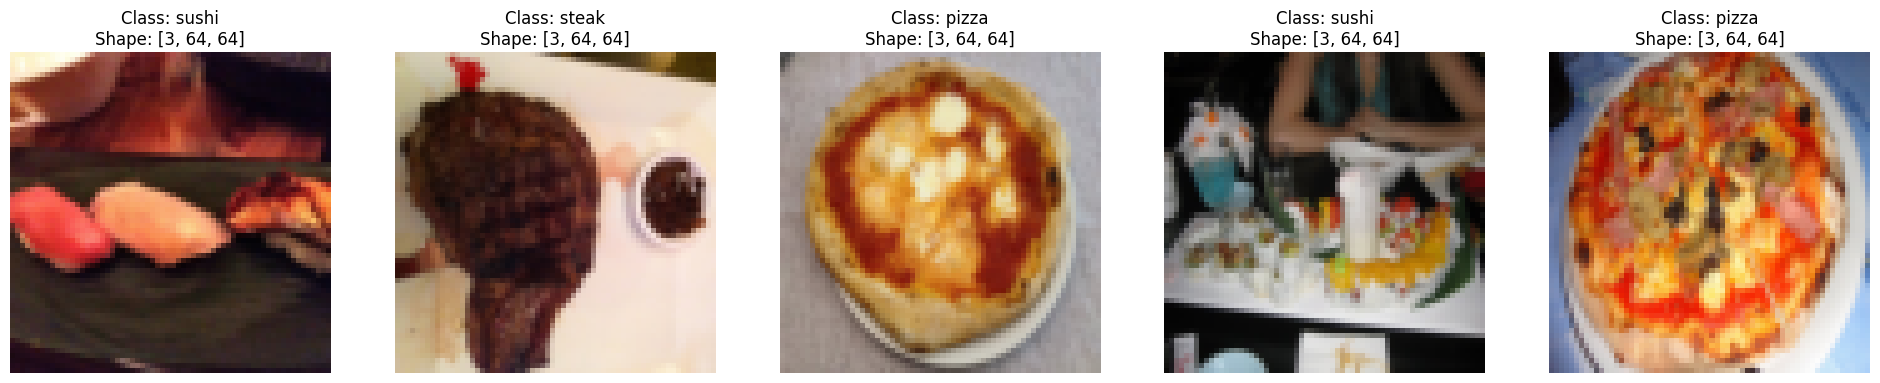

In [ ]:
display_random_images(
    dataset=train_data_custom,
    classes=train_data_custom.classes,
    n=5,
    display_shape=True,
    seed=None
)

In [ ]:
random_samples_idx = random.sample(range(len(train_data_custom)), k=3)
random_samples_idx

[35, 28, 137]

## 5.4 Transforming Custom-loaded images into a DataLoader

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_custom = DataLoader(
    dataset=train_data_custom,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS, # 0 is the default value
    shuffle=True
)
test_dataloader_custom = DataLoader(
    dataset=test_data_custom,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

In [ ]:
train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7a78328809d0>,
 <torch.utils.data.dataloader.DataLoader at 0x7a7833285250>)

In [ ]:
# Get image and label from custom dataloader
img_custom, label_custom = next(iter(train_dataloader_custom)) #Iterating the dataloader gives you batches

img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

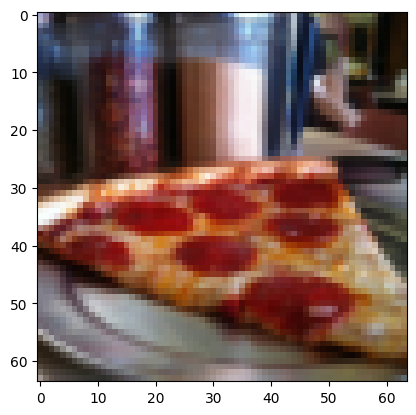

In [ ]:
plt.imshow(img_custom[0].squeeze().permute(1, 2, 0))

# 6. Other forms of transforms (Data Augmentation)

Data agumentation is artificially adding diversity to your training data.

In the case of image data, this may mean applying various image transformations to the training images.

Let's take a look at Data Augmentation for Vision Models.


Increasing diversity helps make it harder for our model to learn the images, instead learning some more abstract ideas about them. Hopefully results in a model that generalizes better to unseen data.

Let's go to Torchvision State of the Arte: "How to train State-of-the-Art Models using TorchVision's latest primitives"

In [ ]:
# Let's look at `trivialaugment`
from torchvision import transforms

train_transform_2 = transforms.Compose([
    transforms.Resize(size=(224, 224)), #A common size in img classification
    transforms.TrivialAugmentWide(num_magnitude_bins=31), #Our augmentation intensity goes from 0 to 5 (if you put 5), so its max is not too intense.
    # The lower this number, the less the maximum upper bound will be
    transforms.ToTensor()
])

test_transform_2 = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()
])

In [ ]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
len(image_path_list), image_path_list[:10]

(300,
 [PosixPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/309892.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/540882.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/971934.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
  PosixPath('data/pizza_steak_sushi/test/pizza/2236338.jpg')])

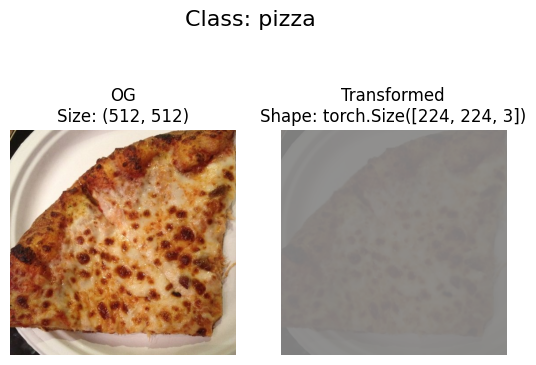

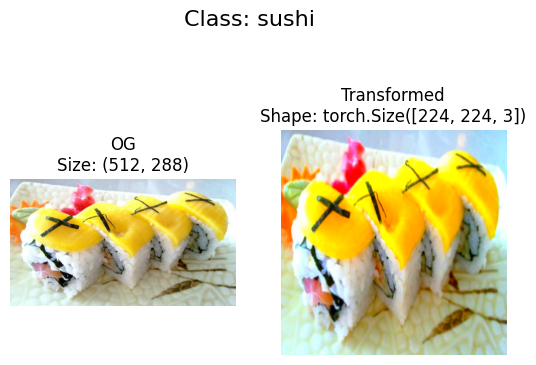

In [ ]:
plot_transformed_images(
    image_paths=image_path_list,
    transform=train_transform_2,
    n=2,
    seed=None
)

# 7. Model 0: Tiny VGG without Data Augmentation

We'll replicate TinyVGG again from the CNN Explainer website.

## 7.1 Creating transforms and loading data for Model 0

In [ ]:
# Create simple transform
# We want to get data from data/pizza_steak_sushi and tranform it into tensors

simple_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [ ]:
# Setup train and testing paths
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [ ]:
# Load some data and transform it
from torchvision import datasets

train_data_simple = datasets.ImageFolder(
    root=train_dir,
    transform=simple_transform,
    target_transform=None
)

test_data_simple = datasets.ImageFolder(
    root=test_dir,
    transform=simple_transform,
    target_transform=None
)

In [ ]:
# Turn datasets into DataLoaders
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(
    dataset=train_data_simple,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True
)
test_dataloader_simple = DataLoader(
    dataset=test_data_simple,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False
)

## 7.2 Create TinyVGG model class

In [ ]:
len(class_names)

3

In [ ]:
from torch import nn

class TinyVGG(nn.Module):
  def __init__(self, input_shape : int, hidden_units: int, output_shape : int):
    super().__init__()
    self.block1 = nn.Sequential(
        nn.Conv2d(
            in_channels= input_shape,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=0
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels= hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=0
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2) #When we don't specify the stride, it is equal to kernel size
    )
    self.block2 = nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=0
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels= hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=0
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_units*13*13,#*16*16,
            out_features=output_shape
        )
    )

  def forward(self, x):
    x = self.block1(x)
    #print(f"Shape: {x.shape}")
    x = self.block2(x)
    #print(f"Shape: {x.shape}")
    return self.classifier(x)

# 7.3 Forward pass on a single image to test what output shape we're expecting.

In [ ]:
img.shape

torch.Size([32, 3, 64, 64])

In [ ]:
model = None
model_0 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

In [ ]:
print(img[0].shape)

model_0(img[0].unsqueeze(dim=0).to(device))

torch.Size([3, 64, 64])


tensor([[ 0.0195,  0.0129, -0.0013]], grad_fn=<AddmmBackward0>)

In [ ]:
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
model_0(image_batch.to(device))

tensor([[ 0.0190,  0.0240,  0.0025],
        [ 0.0180,  0.0238, -0.0003],
        [ 0.0172,  0.0177, -0.0056],
        [ 0.0198,  0.0206, -0.0031],
        [ 0.0143,  0.0206, -0.0029],
        [ 0.0169,  0.0183, -0.0016],
        [ 0.0186,  0.0131, -0.0030],
        [ 0.0210,  0.0161, -0.0056],
        [ 0.0202,  0.0179, -0.0054],
        [ 0.0211,  0.0243, -0.0058],
        [ 0.0158,  0.0201, -0.0040],
        [ 0.0155,  0.0203, -0.0015],
        [ 0.0213,  0.0188, -0.0045],
        [ 0.0187,  0.0219, -0.0055],
        [ 0.0198,  0.0142, -0.0045],
        [ 0.0190,  0.0217, -0.0038],
        [ 0.0194,  0.0210, -0.0053],
        [ 0.0144,  0.0237, -0.0010],
        [ 0.0206,  0.0165, -0.0041],
        [ 0.0165,  0.0195, -0.0026],
        [ 0.0143,  0.0198, -0.0041],
        [ 0.0222,  0.0196, -0.0017],
        [ 0.0145,  0.0210, -0.0022],
        [ 0.0177,  0.0216, -0.0033],
        [ 0.0167,  0.0207, -0.0049],
        [ 0.0188,  0.0205, -0.0052],
        [ 0.0178,  0.0222, -0.0025],
 

What we need to match here are the inner dimensions, don't forget that!

## 7.2 Printing a summary of our model using TorchInfo

With `torchinfo` we can get an idea of the shapes going into the layers.

In [ ]:
# Install torchinfo and import if available
try:
  import torchinfo
except:
  !pip install torchinfo -q
  import torchinfo

In [ ]:
from torchinfo import summary
model_info = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(class_names)
)
summary(model_info, input_size=[1, 3, 64, 64]) #Make sure to get the input size right here, or it won't run right

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

# 8. Building the Train and Test functions for our model

In [ ]:
def train_step(
    model : torch.nn.Module,
    train_dataloader : torch.utils.data.DataLoader,
    optimizer : torch.optim.Optimizer,
    loss_fn : torch.nn.Module
):
  model.train()
  train_loss, train_acc = 0, 0

  for index, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)

    # Forward pass
    y_logits = model(X)

    # Loss
    loss = loss_fn(y_logits, y)
    train_loss += loss.item()

    # Accuracy
    y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
    train_acc += ( (y_preds == y).sum().item() ) / len(y_preds)

    # Optimizer zero grad
    optimizer.zero_grad()

    # Gradient Descent for this batch
    loss.backward()

    optimizer.step()

  #Getting the average (outside of the batch loop, of course)
  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)
  return train_loss, train_acc

In [ ]:
def test_step(
    model : torch.nn.Module,
    test_dataloader : torch.utils.data.DataLoader,
    loss_fn : torch.nn.Module,
    device=device
):
  model.eval()
  test_loss, test_acc = 0, 0

  for index, (X_test, y_test) in enumerate(test_dataloader):
    X_test, y_test = X_test.to(device), y_test.to(device)

    y_test_logits = model(X_test)

    y_test_loss = loss_fn(y_test_logits, y_test)
    test_loss += y_test_loss.item()

    y_test_preds = torch.argmax(torch.softmax(y_test_logits, dim=1), dim=1) # You could directly take the argmax, actutally.
    test_acc += ( (y_test_preds == y_test).sum().item() ) / len(y_test_preds)

  test_loss /= len(test_dataloader)
  test_acc /= len(test_dataloader)
  return test_loss, test_acc


In [ ]:
from tqdm.auto import tqdm

def train(
    model: torch.nn.Module,
    train_dataloader : torch.utils.data.DataLoader,
    test_dataloader : torch.utils.data.DataLoader,
    loss_fn : torch.nn.Module,
    optimizer : torch.optim.Optimizer,
    epochs: int = 5,
    device : torch.device = device
):
  # 2. Create an empty Results Dictionary, much like we did before to show loss and accuracy changing through the epochs.
  results = {
      "train_loss" : [],
      "train_acc" : [],
      "test_loss" : [],
      "test_acc" : [],
      "epoch": []
  }

  # 3. Training loop
  for epoch in tqdm(range(epochs)):
    if epoch % 1 == 0:
      print(f"Epoch {epoch}")

    train_loss, train_acc = train_step(
        model=model,
        train_dataloader=train_dataloader,
        optimizer=optimizer,
        loss_fn=loss_fn
    )

    test_loss, test_acc = test_step(
        model=model,
        test_dataloader=test_dataloader,
        loss_fn=loss_fn,
        device=device
    )

    if epoch % 1 == 0:
      # 4. Print progress
      print(f"Tr. Acc: {train_acc:.2f} | Tr. Loss: {train_loss:.4f} | Te. Acc: {test_acc:.2f} | Te. Loss: {test_loss:.4f}")

    # 5. Update results dictionary
    if epoch % 1 == 0:
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)
      results["epoch"].append(epoch)
  return results

# 9. Train and evaluate model 0

In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params= model_0.parameters(),
    lr=0.1
)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

model_0 = TinyVGG(
    input_shape=3,
    hidden_units=10,
    output_shape=len(train_data.classes)
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_0.parameters(),
    lr=0.001
) #Often times different variables in the PyTorch libraries have defaults that work well, but you can experiment as well.

from timeit import default_timer as timer

start_time = timer()

# Train model_0

model_0_results = train(
    model=model_0,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn = loss_fn,
    optimizer=optimizer,
    epochs=NUM_EPOCHS,
    device=device
)

end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds.")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
Tr. Acc: 0.31 | Tr. Loss: 1.1064 | Te. Acc: 0.26 | Te. Loss: 1.0987
Epoch 1
Tr. Acc: 0.33 | Tr. Loss: 1.1003 | Te. Acc: 0.54 | Te. Loss: 1.0704
Epoch 2
Tr. Acc: 0.36 | Tr. Loss: 1.0881 | Te. Acc: 0.41 | Te. Loss: 1.0827
Epoch 3
Tr. Acc: 0.39 | Tr. Loss: 1.0872 | Te. Acc: 0.60 | Te. Loss: 1.0604
Epoch 4
Tr. Acc: 0.41 | Tr. Loss: 1.0667 | Te. Acc: 0.54 | Te. Loss: 1.0689
Total training time: 17.938 seconds.


# 10. Plotting loss curves of our model.

A loss curve is a way of tracking your model's progress over time. The ideal loss curve is monotonically decreasing.

In [ ]:
# Get model_0_results.keys()
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc', 'epoch'])

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
  """Plots training curves of our results dictionary
  """
  # Get the loss values of the results dictionary (Training and Test)
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  # Get the accuracy values of the results dictionary (train and test)
  train_acc = results["train_acc"]
  test_acc = results["test_acc"]

  # Getting the epochs
  epochs = results["epoch"]

  # Plot setup
  plt.figure(figsize=(15, 7))

  # Plot the loss
  plt.subplot(1, 2, 1) # 1 row, two columns, first let's tackle the first image
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()

  plt.subplot(1, 2, 2) # 1 row, 2 columns, tackling the second image
  plt.plot(epochs, train_acc, label="train_acc")
  plt.plot(epochs, test_acc, label="test_acc")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()



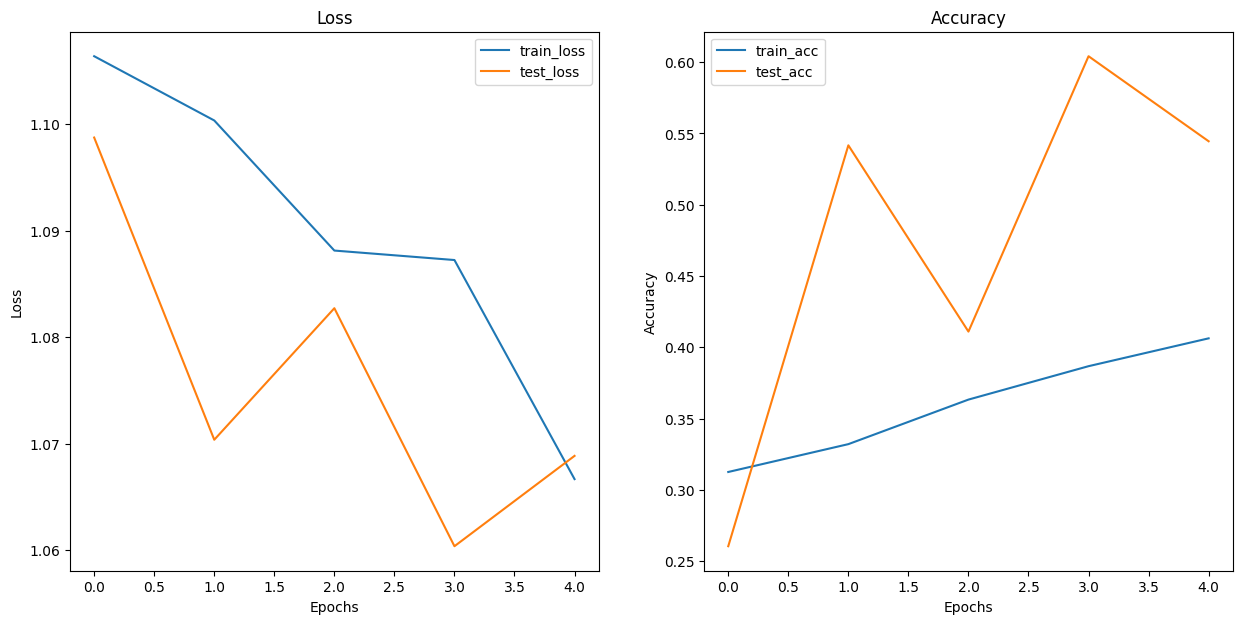

In [ ]:
plot_loss_curves(model_0_results)

In my case seems like the model is very much overfitting to the training dataset.

I am training another one from scratch, let's see if the model is better without it.

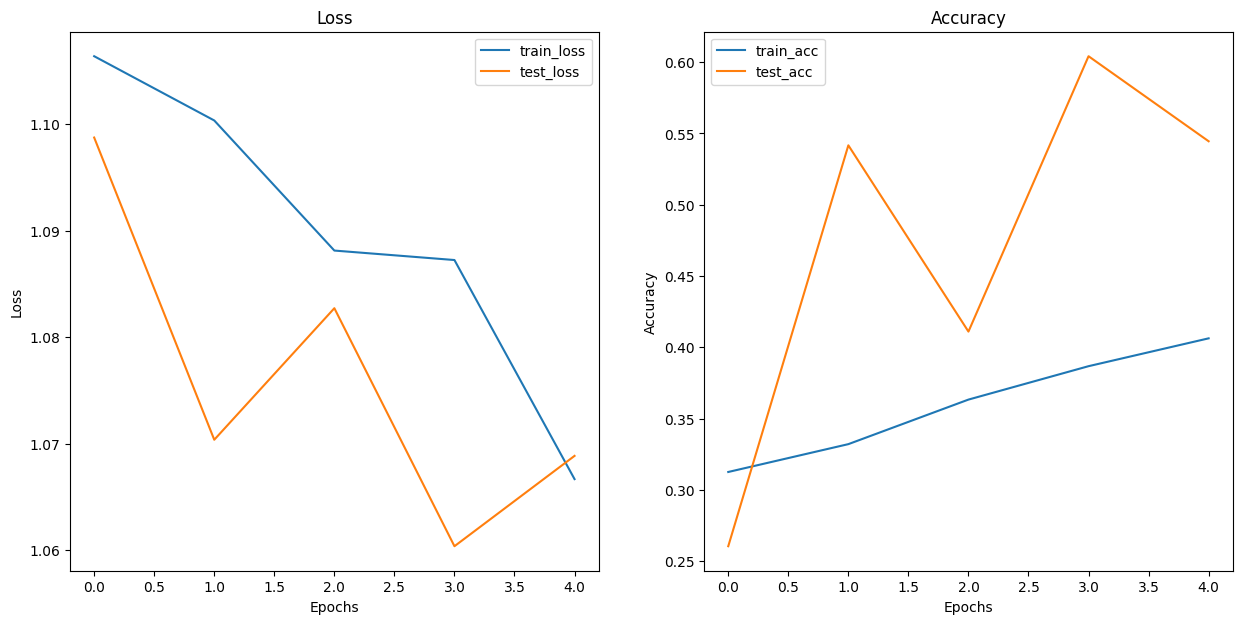

In [ ]:
plot_loss_curves(model_0_results)

Again, overfitting pretty quickly.

## 10.1 What should an ideal Loss Curve look like?

It should be monotonically decreasing, of course, you won't always see that.


- Learning Rate Scheduling with `torch.optim.lr_scheduler`

```
scheduler = ExponentialLR(optimizer, gamma=0.9)
    
for epoch in range(20):
  for input, target in dataset:
    optimizer.zero_grad()
    ...
    optimizer.step()
  scheduler.step()
```

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


# 11. TinyVGG with Data Augmentation

Now let's try another modelling experiment, this time using the same model as before, but with some Data Augmentation

In [ ]:
from torchvision import transforms

train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

## 11.1 Create train and test `Dataset`s and `DataLoader`s using these transforms.

We're still using pizza_steak_sushi

In [ ]:
# Turn image folders into Datasets
train_data_augmented = datasets.ImageFolder(
    root = train_dir,
    transform=train_transform_trivial
)

test_data_simple = datasets.ImageFolder(
    root = test_dir,
    transform=test_transform_simple
)

In [ ]:
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(
    dataset=train_data_augmented,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)
test_dataloader_simple = DataLoader(
    dataset=test_data_simple,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [ ]:
train_dataloader_augmented, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x7a783281de50>,
 <torch.utils.data.dataloader.DataLoader at 0x7a78334f9250>)

## 11.2 Creating Model 1 with our existing TinyVGG class

This time, we've augmented the Training Data.

In [ ]:
model_1 = TinyVGG(
    input_shape = 3,
    hidden_units = 10,
    output_shape = len(class_names)
).to(device)
model_1

TinyVGG(
  (block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model_1.parameters(),
    lr=0.001
)

from timeit import default_timer as timer
start_time = timer()

model_1_results = train(
    model = model_1,
    train_dataloader = train_dataloader_augmented,
    test_dataloader = test_dataloader_simple,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=NUM_EPOCHS,
    device=device
)

end_time = timer()
print(f"Training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
Tr. Acc: 0.25 | Tr. Loss: 1.1049 | Te. Acc: 0.26 | Te. Loss: 1.1019
Epoch 1
Tr. Acc: 0.43 | Tr. Loss: 1.0807 | Te. Acc: 0.26 | Te. Loss: 1.1261
Epoch 2
Tr. Acc: 0.43 | Tr. Loss: 1.0712 | Te. Acc: 0.26 | Te. Loss: 1.1593
Epoch 3
Tr. Acc: 0.30 | Tr. Loss: 1.1253 | Te. Acc: 0.26 | Te. Loss: 1.1581
Epoch 4
Tr. Acc: 0.43 | Tr. Loss: 1.0865 | Te. Acc: 0.33 | Te. Loss: 1.1554
Training time: 16.397 seconds


## 11.3 Plotting loss curve

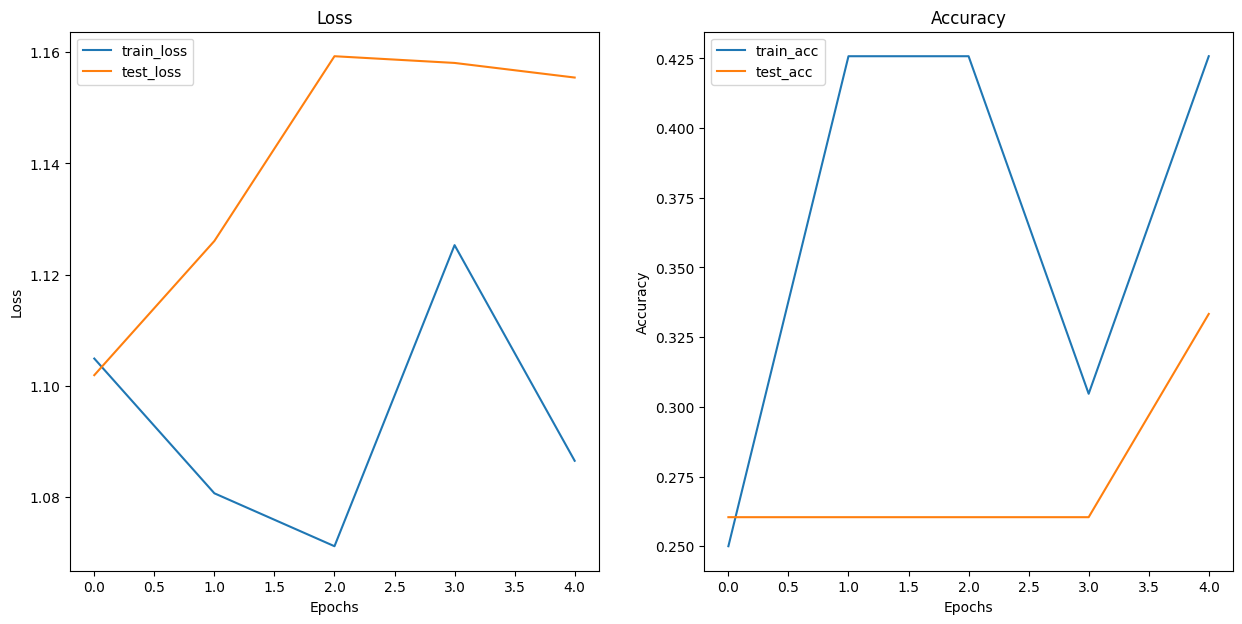

In [ ]:
plot_loss_curves(model_1_results)

## 12. Compare model results

After evaluating our modelling experiments on their own, let's compare them to each other.

There's a few different ways to do it

1. Custom visualization (coding)
2. PyTorch TensorBoard
3. Weights & Biases (auto tracking of experiments).
  - [https://wandb.ai/site/](https://wandb.ai/site/)
  - Tracks model hyperparameters
4. MLFlow

In [ ]:
import pandas as pd

model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df


,train_loss,train_acc,test_loss,test_acc,epoch
0,1.106372,0.312500,1.098738,0.260417,0
1,1.100340,0.332031,1.070369,0.541667,1
2,1.088129,0.363281,1.082717,0.410985,2
3,1.087240,0.386719,1.060374,0.604167,3
4,1.066674,0.406250,1.068856,0.544508,4


Text(0.5, 1.0, 'Test Accuracy')

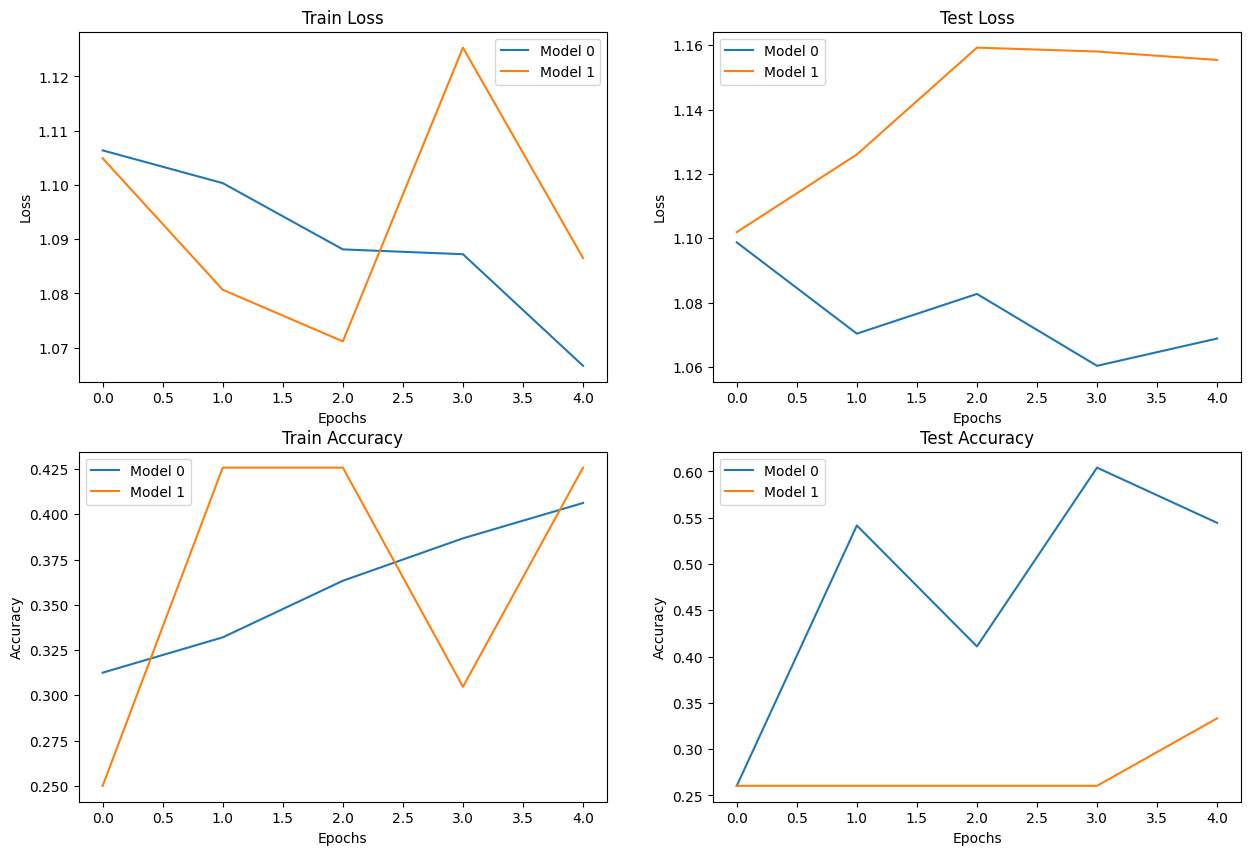

In [ ]:
plt.figure(figsize=(15, 10))

epochs = range(len(model_0_df))

plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train Loss")

plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Test Loss")

plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label="Model 0")
plt.plot(epochs, model_1_df["train_acc"], label="Model 1")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train Accuracy")

plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label="Model 0")
plt.plot(epochs, model_1_df["test_acc"], label="Model 1")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Test Accuracy")

# 13. Making a prediction on a custom image

In [ ]:
import requests

# Setup custom image path
custom_image_path = data_path / "04_pizza_dad.jpeg"

# Download the image if it doesn't exist
if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    # When downloading from Github, get the Raw link.
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/images/04-pizza-dad.jpeg")
    print(f"Downloading {custom_image_path}... ")
    f.write(request.content)
else:
  print(f"{custom_image_path} already exists, skipping download")


## 13.1 Loading in a custom image with PyTorch

Let's check that our custom image is in the same format as the data our model was trained on

* A Torch.Tensor with datatype `torch.float32`
* Of shape [64, 64, 3]
* On the right device

In [ ]:
import torchvision

# Whichever library you load depends on your current domain, we're working with images, so torchvision.
# We want to read an image, so in the Torchvision documentation, see `Reading/Writing images and videos`

custom_image_uint8 = torchvision.io.read_image(
    path=custom_image_path
)
custom_image_uint8.shape

# Before it didn't accept a posixpath, but it seems like now it does.
# you would need `str(your_PosixPath)`

torch.Size([3, 4032, 3024])

Text(0.5, 1.0, 'Hello!')

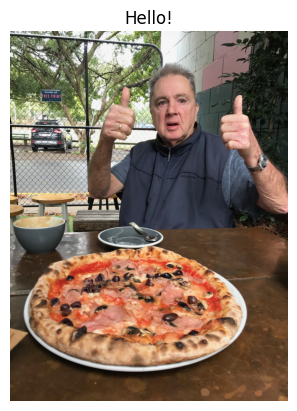

In [ ]:
plt.imshow(custom_image_uint8.permute(1, 2, 0))
plt.axis(False)
plt.title("Hello!")

In [ ]:
print(custom_image_uint8.shape)
print(custom_image_uint8.dtype)

torch.Size([3, 4032, 3024])
torch.uint8


We'll have to change the shape to adapt it to our model, and the datatype is different from what we wanted

In [ ]:
custom_image_float32 = custom_image_uint8.to(torch.float32)
custom_image_float32.dtype
custom_image_float32 = custom_image_float32 / 255.
custom_image_float32.shape

torch.Size([3, 4032, 3024])

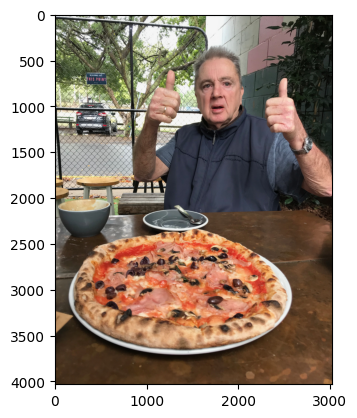

In [ ]:
plt.imshow(custom_image_float32.permute(1, 2, 0))

In [ ]:
# Create a pipeline to resize image
from torchvision import transforms
custom_imgt = transforms.Compose([
    transforms.Resize(size=(64, 64))
])

In [ ]:
custom_image = custom_imgt(custom_image_float32)
custom_image.shape

torch.Size([3, 64, 64])

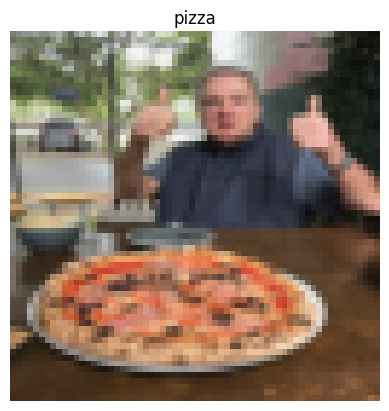

In [ ]:
model_1.eval()
with torch.inference_mode():
  y_pred = model_1(custom_image.unsqueeze(dim=0))
  y_cat = torch.argmax(y_pred, dim=1)
  y_pred = class_names[y_cat]
plt.imshow(custom_image.permute(1, 2, 0))
plt.title(y_pred)
plt.axis(False);

## 13.2 Custom image prediction and plot function

In [ ]:
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

def predict_and_display(image_path, model : torch.nn.Module, class_names : List[str] = None, transform=None, device=device):
  target_image = torchvision.io.read_image(
      path=image_path
  ).type(torch.float32)
  target_image /= 255.

  if transform:
    target_image = transform(target_image)

  model.eval()
  with torch.inference_mode():
    y_pred_prob = torch.softmax(model(target_image.unsqueeze(dim=0).to(device)), dim=1)
    y_pred = torch.argmax(y_pred_prob, dim=1)

  plt.imshow(target_image.permute(1, 2, 0))
  plt.axis(False)
  plt.title(f"{class_names[y_pred]} | Prob: {y_pred_prob[0][y_pred].item():.3f}" )

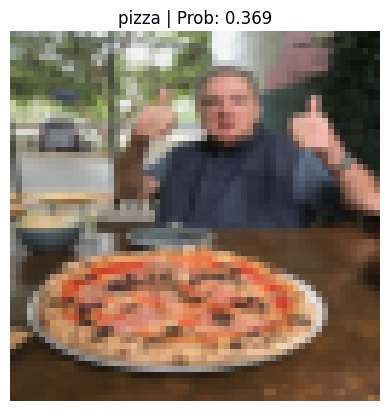

In [ ]:
predict_and_display(
    image_path=custom_image_path,
    model=model_1,
    class_names=class_names,
    transform=custom_imgt,
    device="cpu"
)

# 14. ChatGPT Erasure of widget metadata

In [ ]:
import nbformat

notebook_path = '/content/drive/MyDrive/Colab Notebooks/04_pytorch_custom_datasets.ipynb'  # Update as needed

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']
    print("Removed 'widgets' metadata.")
else:
    print("No 'widgets' metadata found.")

with open(notebook_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)
    print("Notebook cleaned and saved back to Drive.")
